# ML Project - Training Certifications

Authentic machine learning notebook for the Smart Freelance Platform.

This version is aligned with the backend entities:
- `Training`
- `Review`
- `Certification`

It is designed to be more defendable during the PI validation:
- stronger business framing
- more realistic synthetic data
- explicit data quality checks
- leakage control
- threshold selection to avoid one-class predictions
- deployment plan consistent with a Java backend

## 0. Install Dependencies

Run this cell once if the machine does not already have the required Python packages.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports And Configuration

In [2]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

SNAPSHOT_DATE = pd.Timestamp('2026-04-16')

DATA_DIR = Path('ml_data')
MODEL_DIR = Path('ml_models')
REPORT_DIR = Path('ml_reports')
DATA_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

DATASET_PATH = DATA_DIR / 'training_certifications_dataset.csv'
MODELING_DATASET_PATH = DATA_DIR / 'completed_training_certifications_dataset.csv'
MODEL_PATH = MODEL_DIR / 'certification_issued_pipeline.joblib'
RESULTS_PATH = REPORT_DIR / 'model_comparison_results.csv'
QUALITY_PATH = REPORT_DIR / 'data_quality_report.csv'

SNAPSHOT_DATE

Timestamp('2026-04-16 00:00:00')

## 2. Business Understanding

Business question:
- after a learner finishes a training, can we estimate the probability that the certification will be issued?

Business value for the platform:
- identify at-risk learners before the certification decision is finalized
- help managers trigger mentoring, reminders, or remediation actions
- support reporting on training effectiveness by category

Target definition:
- `is_issued = 1` when the certification status becomes `ISSUED` or `EXPIRED`
- `is_issued = 0` when the certification is still `PENDING` or becomes `REVOKED`

Important modeling choice:
- the final model is trained only on `COMPLETED` trainings
- this is more authentic because certification issuance is evaluated after the learning process is finished
- it also avoids a trivial model that would mostly learn that `UPCOMING` and `CANCELLED` trainings cannot produce issued certifications

## 3. Domain Alignment With The Backend

The notebook is intentionally aligned with the existing Java entities:

`Training.java`
- `title`
- `category`
- `durationHours`
- `startDate`
- `endDate`
- `status`

`Review.java`
- `rating`
- `status`
- `createdAt`

`Certification.java`
- `certificateNumber`
- `issueDate`
- `expiryDate`
- `status`
- `grade`
- `score`
- `clientId`

This makes the dataset more realistic than a generic tutorial dataset, even though it is still synthetic.

## 4. Generate A More Authentic Synthetic Dataset

The data is still synthetic, but the generation logic is closer to a real platform snapshot:
- dates are coherent with the fixed snapshot date `2026-04-16`
- `UPCOMING`, `ONGOING`, `COMPLETED`, and `CANCELLED` trainings follow explicit date rules
- completed trainings may lead to `ISSUED`, `PENDING`, `REVOKED`, or `EXPIRED` certifications depending on historical context
- review quality, attendance, engagement, and exam results are linked together instead of being random independent columns
- a few missing values are intentionally injected to simulate realistic operational data

In [3]:
category_config = {
    'Web Development': {'prob': 0.22, 'mean_hours': 44, 'effect': 0.10},
    'Data Science': {'prob': 0.17, 'mean_hours': 58, 'effect': 0.30},
    'Cloud': {'prob': 0.16, 'mean_hours': 52, 'effect': 0.24},
    'UI/UX': {'prob': 0.12, 'mean_hours': 36, 'effect': 0.08},
    'Cybersecurity': {'prob': 0.18, 'mean_hours': 54, 'effect': 0.28},
    'Mobile': {'prob': 0.15, 'mean_hours': 40, 'effect': 0.12},
}

status_options = ['UPCOMING', 'ONGOING', 'COMPLETED', 'CANCELLED']
status_probs = [0.12, 0.21, 0.55, 0.12]

cohort_profiles = {
    'AT_RISK': {'prob': 0.27, 'ability_mean': 47, 'motivation_mean': 44},
    'STEADY': {'prob': 0.48, 'ability_mean': 65, 'motivation_mean': 66},
    'EXCELLENT': {'prob': 0.25, 'ability_mean': 84, 'motivation_mean': 83},
}

categories = list(category_config.keys())
category_probs = [cfg['prob'] for cfg in category_config.values()]
cohorts = list(cohort_profiles.keys())
cohort_probs = [cfg['prob'] for cfg in cohort_profiles.values()]


def build_dates(status, duration_days):
    if status == 'UPCOMING':
        start_date = SNAPSHOT_DATE + pd.Timedelta(days=int(np.random.randint(3, 46)))
        end_date = start_date + pd.Timedelta(days=duration_days)
        cancel_date = pd.NaT
    elif status == 'ONGOING':
        start_date = SNAPSHOT_DATE - pd.Timedelta(days=int(np.random.randint(4, max(5, duration_days // 2 + 5))))
        end_date = SNAPSHOT_DATE + pd.Timedelta(days=int(np.random.randint(3, max(4, duration_days // 2 + 10))))
        cancel_date = pd.NaT
    elif status == 'COMPLETED':
        end_date = SNAPSHOT_DATE - pd.Timedelta(days=int(np.random.randint(15, 620)))
        start_date = end_date - pd.Timedelta(days=duration_days)
        cancel_date = pd.NaT
    else:
        start_date = SNAPSHOT_DATE - pd.Timedelta(days=int(np.random.randint(15, 220)))
        cancel_offset = int(np.random.randint(0, max(1, duration_days)))
        cancel_date = start_date + pd.Timedelta(days=cancel_offset)
        end_date = cancel_date
    return start_date.normalize(), end_date.normalize(), cancel_date


rows = []
n_samples = 1600

for idx in range(1, n_samples + 1):
    category = np.random.choice(categories, p=category_probs)
    training_status = np.random.choice(status_options, p=status_probs)
    cohort = np.random.choice(cohorts, p=cohort_probs)

    ability = np.clip(np.random.normal(cohort_profiles[cohort]['ability_mean'], 9), 20, 98)
    motivation = np.clip(np.random.normal(cohort_profiles[cohort]['motivation_mean'], 12), 15, 100)

    duration_hours = int(np.clip(np.random.normal(category_config[category]['mean_hours'], 10), 12, 96))
    duration_days = max(3, int(round(duration_hours / 4)))
    start_date, end_date, cancel_date = build_dates(training_status, duration_days)

    attendance_rate = np.round(np.clip(0.40 + 0.0050 * ability + 0.0022 * motivation + np.random.normal(0, 0.07), 0.25, 1.00), 2)

    if training_status == 'UPCOMING':
        completion_rate = np.round(np.clip(np.random.normal(0.05, 0.03), 0.00, 0.16), 2)
    elif training_status == 'ONGOING':
        completion_rate = np.round(np.clip(np.random.normal(0.56 + 0.002 * (ability - 60), 0.11), 0.20, 0.92), 2)
    elif training_status == 'COMPLETED':
        completion_rate = np.round(np.clip(np.random.normal(0.93 + 0.0007 * (ability - 60), 0.05), 0.72, 1.00), 2)
    else:
        completion_rate = np.round(np.clip(np.random.normal(0.26, 0.15), 0.00, 0.72), 2)

    missed_sessions = int(np.clip(np.random.poisson(max(0.2, 5.2 - 4.3 * attendance_rate)), 0, 12))
    prior_certifications = int(np.clip(np.random.poisson(max(0.2, (ability - 32) / 22)), 0, 8))

    review_count = int(np.clip(np.random.poisson(9 if training_status == 'COMPLETED' else 4), 0, 28))

    if review_count > 0:
        approved_review_ratio = np.clip(np.random.normal(0.60 + (motivation - 60) * 0.0032, 0.16), 0.0, 1.0)
        approved_review_count = int(round(review_count * approved_review_ratio))
        rejected_review_count = int(round((review_count - approved_review_count) * np.random.uniform(0.25, 0.65)))
        pending_review_count = max(0, review_count - approved_review_count - rejected_review_count)
        avg_review_rating = np.round(np.clip(np.random.normal(2.7 + 2.0 * approved_review_ratio + (ability - 60) * 0.012, 0.40), 1.0, 5.0), 1)
    else:
        approved_review_ratio = 0.0
        approved_review_count = 0
        rejected_review_count = 0
        pending_review_count = 0
        avg_review_rating = np.nan

    if training_status == 'UPCOMING':
        practice_quiz_avg = np.nan
        assignment_avg = np.nan
        exam_score = np.nan
        days_until_exam = int(np.clip(np.random.normal(24, 7), 4, 50))
    elif training_status == 'ONGOING':
        practice_quiz_avg = np.round(np.clip(np.random.normal(ability + (motivation - 60) * 0.12, 10), 20, 100), 1)
        assignment_avg = np.round(np.clip(np.random.normal(ability + (motivation - 60) * 0.10, 9), 25, 100), 1)
        exam_score = np.nan
        days_until_exam = int(np.clip(np.random.normal(12, 6), 1, 28))
    elif training_status == 'COMPLETED':
        practice_quiz_avg = np.round(np.clip(np.random.normal(ability + (motivation - 60) * 0.15, 9), 20, 100), 1)
        assignment_avg = np.round(np.clip(np.random.normal(ability + (motivation - 60) * 0.14, 8), 25, 100), 1)
        exam_score = np.round(np.clip(np.random.normal(ability + (completion_rate - 0.65) * 28, 8), 20, 100), 1)
        days_until_exam = 0
    else:
        practice_quiz_avg = np.round(np.clip(np.random.normal(ability - 2, 10), 15, 98), 1)
        assignment_avg = np.round(np.clip(np.random.normal(ability - 8, 10), 20, 94), 1)
        exam_score = np.nan
        days_until_exam = int(np.clip(np.random.normal(16, 7), 1, 30))

    engagement_score = np.round(np.clip(np.random.normal(motivation + (attendance_rate - 0.7) * 32, 9), 10, 100), 1)

    if np.random.rand() < 0.06:
        practice_quiz_avg = np.nan
    if np.random.rand() < 0.04:
        avg_review_rating = np.nan
    if training_status == 'COMPLETED' and np.random.rand() < 0.03:
        assignment_avg = np.nan

    quiz_for_score = 58 if pd.isna(practice_quiz_avg) else practice_quiz_avg
    exam_for_score = 54 if pd.isna(exam_score) else exam_score
    assignment_for_score = 56 if pd.isna(assignment_avg) else assignment_avg
    rating_for_score = 3.2 if pd.isna(avg_review_rating) else avg_review_rating

    performance_index = np.round(0.45 * exam_for_score + 0.30 * assignment_for_score + 0.25 * quiz_for_score, 1)
    engagement_index = np.round(0.45 * (attendance_rate * 100) + 0.35 * engagement_score + 0.20 * (100 - 8 * missed_sessions), 1)

    certificate_score = np.round(
        np.clip(
            0.42 * exam_for_score
            + 0.24 * assignment_for_score
            + 0.14 * quiz_for_score
            + 0.12 * engagement_score
            + 0.08 * attendance_rate * 100,
            0,
            100,
        ),
        1,
    )

    if training_status == 'COMPLETED':
        raw_signal = (
            -3.7
            + 0.030 * performance_index
            + 0.014 * engagement_index
            + 0.50 * approved_review_ratio
            + 0.12 * prior_certifications
            - 0.17 * missed_sessions
            + category_config[category]['effect']
            + np.random.normal(0, 0.55)
        )
        if attendance_rate < 0.62:
            raw_signal -= 0.8
        if completion_rate < 0.85:
            raw_signal -= 0.55
        if exam_for_score < 55:
            raw_signal -= 0.70
        if performance_index >= 82 and attendance_rate >= 0.84:
            raw_signal += 0.55

        issue_probability = 1 / (1 + np.exp(-raw_signal))
        is_issued = int(np.random.rand() < issue_probability)
    else:
        issue_probability = 0.0
        is_issued = 0

    if certificate_score >= 90:
        grade = 'A'
    elif certificate_score >= 80:
        grade = 'B'
    elif certificate_score >= 70:
        grade = 'C'
    elif certificate_score >= 60:
        grade = 'D'
    else:
        grade = 'F'

    issue_date = pd.NaT
    expiry_date = pd.NaT

    if training_status == 'COMPLETED' and is_issued == 1:
        issue_date = end_date + pd.Timedelta(days=int(np.random.randint(2, 31)))
        expiry_date = issue_date + pd.Timedelta(days=365)
        certificate_status = 'EXPIRED' if expiry_date < SNAPSHOT_DATE else 'ISSUED'
    elif training_status == 'COMPLETED':
        certificate_status = 'REVOKED' if performance_index < 52 or attendance_rate < 0.45 else 'PENDING'
    elif training_status == 'CANCELLED':
        certificate_status = 'REVOKED'
    else:
        certificate_status = 'PENDING'

    rows.append({
        'training_id': idx,
        'client_id': 1000 + idx,
        'certificate_number': f'CERT-2026-{idx:05d}',
        'training_title': f'{category} Bootcamp {idx}',
        'category': category,
        'duration_hours': duration_hours,
        'training_duration_days': duration_days,
        'start_date': start_date.date().isoformat(),
        'end_date': end_date.date().isoformat(),
        'cancel_date': None if pd.isna(cancel_date) else cancel_date.date().isoformat(),
        'training_status': training_status,
        'review_count': review_count,
        'approved_review_count': approved_review_count,
        'rejected_review_count': rejected_review_count,
        'pending_review_count': pending_review_count,
        'approved_review_ratio': round(float(approved_review_ratio), 2),
        'avg_review_rating': avg_review_rating,
        'attendance_rate': attendance_rate,
        'completion_rate': completion_rate,
        'assignment_avg': assignment_avg,
        'exam_score': exam_score,
        'engagement_score': engagement_score,
        'practice_quiz_avg': practice_quiz_avg,
        'days_until_exam': days_until_exam,
        'missed_sessions': missed_sessions,
        'prior_certifications': prior_certifications,
        'performance_index': performance_index,
        'engagement_index': engagement_index,
        'certificate_score': certificate_score,
        'grade': grade,
        'issue_date': None if pd.isna(issue_date) else issue_date.date().isoformat(),
        'expiry_date': None if pd.isna(expiry_date) else expiry_date.date().isoformat(),
        'certificate_status': certificate_status,
        'issue_probability': round(float(issue_probability), 4),
        'is_issued': is_issued,
    })

df = pd.DataFrame(rows)
df.to_csv(DATASET_PATH, index=False)

print(f'Snapshot date: {SNAPSHOT_DATE.date()}')
print(f'Dataset saved to: {DATASET_PATH.resolve()}')
print('Overall rows:', len(df))
df.head()

Snapshot date: 2026-04-16
Dataset saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_data\training_certifications_dataset.csv
Overall rows: 1400


,training_id,client_id,certificate_number,training_title,category,duration_hours,start_date,end_date,training_status,review_count,...,days_until_exam,missed_sessions,prior_certifications,certificate_score,grade,issue_date,expiry_date,certificate_status,issue_probability,is_issued
0,1,1001,CERT-2026-00001,Data Science Bootcamp 1,Data Science,60,2026-03-14,2026-03-29,CANCELLED,0,...,14,2,2,59.0,F,NaN,NaN,REVOKED,0.0000,0
1,2,1002,CERT-2026-00002,Web Development Bootcamp 2,Web Development,47,2026-02-08,2026-02-20,COMPLETED,5,...,0,0,2,71.2,C,NaN,NaN,PENDING,0.4156,0
2,3,1003,CERT-2026-00003,Cloud Bootcamp 3,Cloud,56,2026-02-06,2026-02-20,CANCELLED,4,...,14,1,3,76.0,C,NaN,NaN,REVOKED,0.0000,0
3,4,1004,CERT-2026-00004,Cloud Bootcamp 4,Cloud,67,2026-05-02,2026-05-19,UPCOMING,1,...,24,0,0,62.0,D,NaN,NaN,PENDING,0.0000,0
4,5,1005,CERT-2026-00005,Data Science Bootcamp 5,Data Science,60,2026-05-08,2026-05-23,UPCOMING,4,...,22,2,0,62.0,D,NaN,NaN,PENDING,0.0000,0


## 5. Data Quality Assessment

This section makes the data preparation step explicit according to the PI criteria:
- actuality: the snapshot date is fixed and explicit
- understandability: each column is interpretable and linked to the backend domain
- relevance: the final feature set focuses only on fields useful for prediction
- validity: ranges, missing values, duplicates, and date logic are checked
- coherence: statuses and dates must agree with each other
- accessibility: datasets, reports, and model artifacts are exported to disk

In [4]:
quality_report = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(dtype) for dtype in df.dtypes],
    'missing_values': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values,
    'unique_values': df.nunique().values,
})

duplicate_rows = int(df.duplicated().sum())
duplicate_training_client_keys = int(df.duplicated(subset=['training_id', 'client_id']).sum())

date_df = df.copy()
date_df['start_date'] = pd.to_datetime(date_df['start_date'])
date_df['end_date'] = pd.to_datetime(date_df['end_date'])
date_df['cancel_date'] = pd.to_datetime(date_df['cancel_date'])
date_df['issue_date'] = pd.to_datetime(date_df['issue_date'])
date_df['expiry_date'] = pd.to_datetime(date_df['expiry_date'])

validity_checks = {
    'duration_hours_valid': df['duration_hours'].between(12, 96).all(),
    'training_duration_days_valid': df['training_duration_days'].between(3, 30).all(),
    'avg_review_rating_valid': df['avg_review_rating'].dropna().between(1, 5).all(),
    'attendance_rate_valid': df['attendance_rate'].between(0, 1).all(),
    'completion_rate_valid': df['completion_rate'].between(0, 1).all(),
    'assignment_avg_valid': df['assignment_avg'].dropna().between(0, 100).all(),
    'exam_score_valid': df['exam_score'].dropna().between(0, 100).all(),
    'practice_quiz_avg_valid': df['practice_quiz_avg'].dropna().between(0, 100).all(),
    'engagement_score_valid': df['engagement_score'].between(0, 100).all(),
    'approved_review_ratio_valid': df['approved_review_ratio'].between(0, 1).all(),
}

coherence_checks = {
    'end_date_after_start_date': (date_df['end_date'] >= date_df['start_date']).all(),
    'upcoming_starts_after_snapshot': (date_df.loc[df['training_status'] == 'UPCOMING', 'start_date'] > SNAPSHOT_DATE).all(),
    'ongoing_crosses_snapshot': (
        (date_df.loc[df['training_status'] == 'ONGOING', 'start_date'] <= SNAPSHOT_DATE)
        & (date_df.loc[df['training_status'] == 'ONGOING', 'end_date'] >= SNAPSHOT_DATE)
    ).all(),
    'completed_ended_before_snapshot': (date_df.loc[df['training_status'] == 'COMPLETED', 'end_date'] < SNAPSHOT_DATE).all(),
    'cancelled_has_cancel_date': date_df.loc[df['training_status'] == 'CANCELLED', 'cancel_date'].notna().all(),
    'cancelled_end_matches_cancel_date': (
        date_df.loc[df['training_status'] == 'CANCELLED', 'end_date']
        == date_df.loc[df['training_status'] == 'CANCELLED', 'cancel_date']
    ).all(),
    'issued_rows_have_issue_date': date_df.loc[df['is_issued'] == 1, 'issue_date'].notna().all(),
    'issued_rows_after_training_end': (
        date_df.loc[df['is_issued'] == 1, 'issue_date']
        >= date_df.loc[df['is_issued'] == 1, 'end_date']
    ).all(),
    'issued_rows_have_valid_status': df.loc[df['is_issued'] == 1, 'certificate_status'].isin(['ISSUED', 'EXPIRED']).all(),
    'non_issued_rows_have_non_issued_status': df.loc[df['is_issued'] == 0, 'certificate_status'].isin(['PENDING', 'REVOKED']).all(),
    'expiry_after_issue_when_present': (
        date_df.loc[date_df['expiry_date'].notna(), 'expiry_date']
        >= date_df.loc[date_df['expiry_date'].notna(), 'issue_date']
    ).all(),
    'unique_training_client_key': duplicate_training_client_keys == 0,
}

quality_summary = pd.DataFrame({
    'check': list(validity_checks.keys()) + list(coherence_checks.keys()),
    'passed': list(validity_checks.values()) + list(coherence_checks.values()),
})

print('Duplicate rows:', duplicate_rows)
print('Duplicate training/client keys:', duplicate_training_client_keys)
print('\nQuality summary:')
display(quality_summary)

print('\nColumn-level quality report:')
display(quality_report)

quality_report.to_csv(QUALITY_PATH, index=False)
print(f'Quality report saved to: {QUALITY_PATH.resolve()}')

Duplicate rows: 0
Duplicate training/client keys: 0

Quality summary:


,check,passed
0,duration_hours_valid,True
1,avg_review_rating_valid,True
2,attendance_rate_valid,True
3,completion_rate_valid,True
4,assignment_avg_valid,True
5,exam_score_valid,True
6,practice_quiz_avg_valid,True
7,engagement_score_valid,True
8,approved_review_ratio_valid,True
9,end_date_after_start_date,True



Column-level quality report:


,column,dtype,missing_values,missing_pct,unique_values
0,training_id,int64,0,0.00,1400
1,client_id,int64,0,0.00,1400
2,certificate_number,str,0,0.00,1400
3,training_title,str,0,0.00,1400
4,category,str,0,0.00,6
5,duration_hours,int64,0,0.00,68
6,start_date,str,0,0.00,233
7,end_date,str,0,0.00,240
8,training_status,str,0,0.00,4
9,review_count,int64,0,0.00,20


Quality report saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_reports\data_quality_report.csv


## 6. Exploratory Data Analysis

In [5]:
modeling_df = df[df['training_status'] == 'COMPLETED'].copy()

modeling_df['start_date'] = pd.to_datetime(modeling_df['start_date'])
modeling_df['end_date'] = pd.to_datetime(modeling_df['end_date'])
modeling_df['issue_date'] = pd.to_datetime(modeling_df['issue_date'])

modeling_df['days_since_training_end'] = (SNAPSHOT_DATE - modeling_df['end_date']).dt.days
modeling_df['days_to_issue'] = (modeling_df['issue_date'] - modeling_df['end_date']).dt.days
modeling_df['review_quality_index'] = modeling_df['approved_review_ratio'] * modeling_df['avg_review_rating'].fillna(modeling_df['avg_review_rating'].median())
modeling_df['score_consistency'] = (modeling_df['assignment_avg'].fillna(modeling_df['assignment_avg'].median()) - modeling_df['exam_score'].fillna(modeling_df['exam_score'].median())).abs()
modeling_df['engagement_gap'] = (modeling_df['engagement_index'] - modeling_df['performance_index']).abs()

modeling_df.to_csv(MODELING_DATASET_PATH, index=False)

print('Full dataset shape:', df.shape)
print('Completed-only modeling dataset shape:', modeling_df.shape)
print('\nTraining status distribution:')
display(df['training_status'].value_counts().rename_axis('training_status').reset_index(name='count'))

print('\nCertification status distribution:')
display(df['certificate_status'].value_counts().rename_axis('certificate_status').reset_index(name='count'))

print('\nTarget balance on completed trainings:')
display(modeling_df['is_issued'].value_counts(normalize=True).rename('share').reset_index(name='share'))

display(modeling_df.head())

Full dataset shape: (1400, 31)
Completed-only modeling dataset shape: (797, 31)

Training status distribution:


,training_status,count
0,COMPLETED,797
1,ONGOING,298
2,UPCOMING,175
3,CANCELLED,130



Certification status distribution:


,certificate_status,count
0,PENDING,705
1,ISSUED,401
2,REVOKED,294



Target balance on completed trainings:


,is_issued,share
0,1,0.503137
1,0,0.496863


,training_id,client_id,certificate_number,training_title,category,duration_hours,start_date,end_date,training_status,review_count,...,days_until_exam,missed_sessions,prior_certifications,certificate_score,grade,issue_date,expiry_date,certificate_status,issue_probability,is_issued
1,2,1002,CERT-2026-00002,Web Development Bootcamp 2,Web Development,47,2026-02-08,2026-02-20,COMPLETED,5,...,0,0,2,71.2,C,NaN,NaN,PENDING,0.4156,0
5,6,1006,CERT-2026-00006,Cloud Bootcamp 6,Cloud,35,2025-12-11,2025-12-20,COMPLETED,9,...,3,1,2,64.1,D,NaN,NaN,PENDING,0.3345,0
6,7,1007,CERT-2026-00007,Cloud Bootcamp 7,Cloud,70,2026-03-18,2026-04-05,COMPLETED,11,...,10,1,0,67.0,D,NaN,NaN,PENDING,0.4741,0
7,8,1008,CERT-2026-00008,Cybersecurity Bootcamp 8,Cybersecurity,46,2025-12-02,2025-12-14,COMPLETED,10,...,6,3,0,62.1,D,NaN,NaN,PENDING,0.2356,0
8,9,1009,CERT-2026-00009,Cloud Bootcamp 9,Cloud,43,2026-03-15,2026-03-26,COMPLETED,2,...,1,0,1,86.7,B,2026-04-11,2027-04-11,ISSUED,0.8286,1


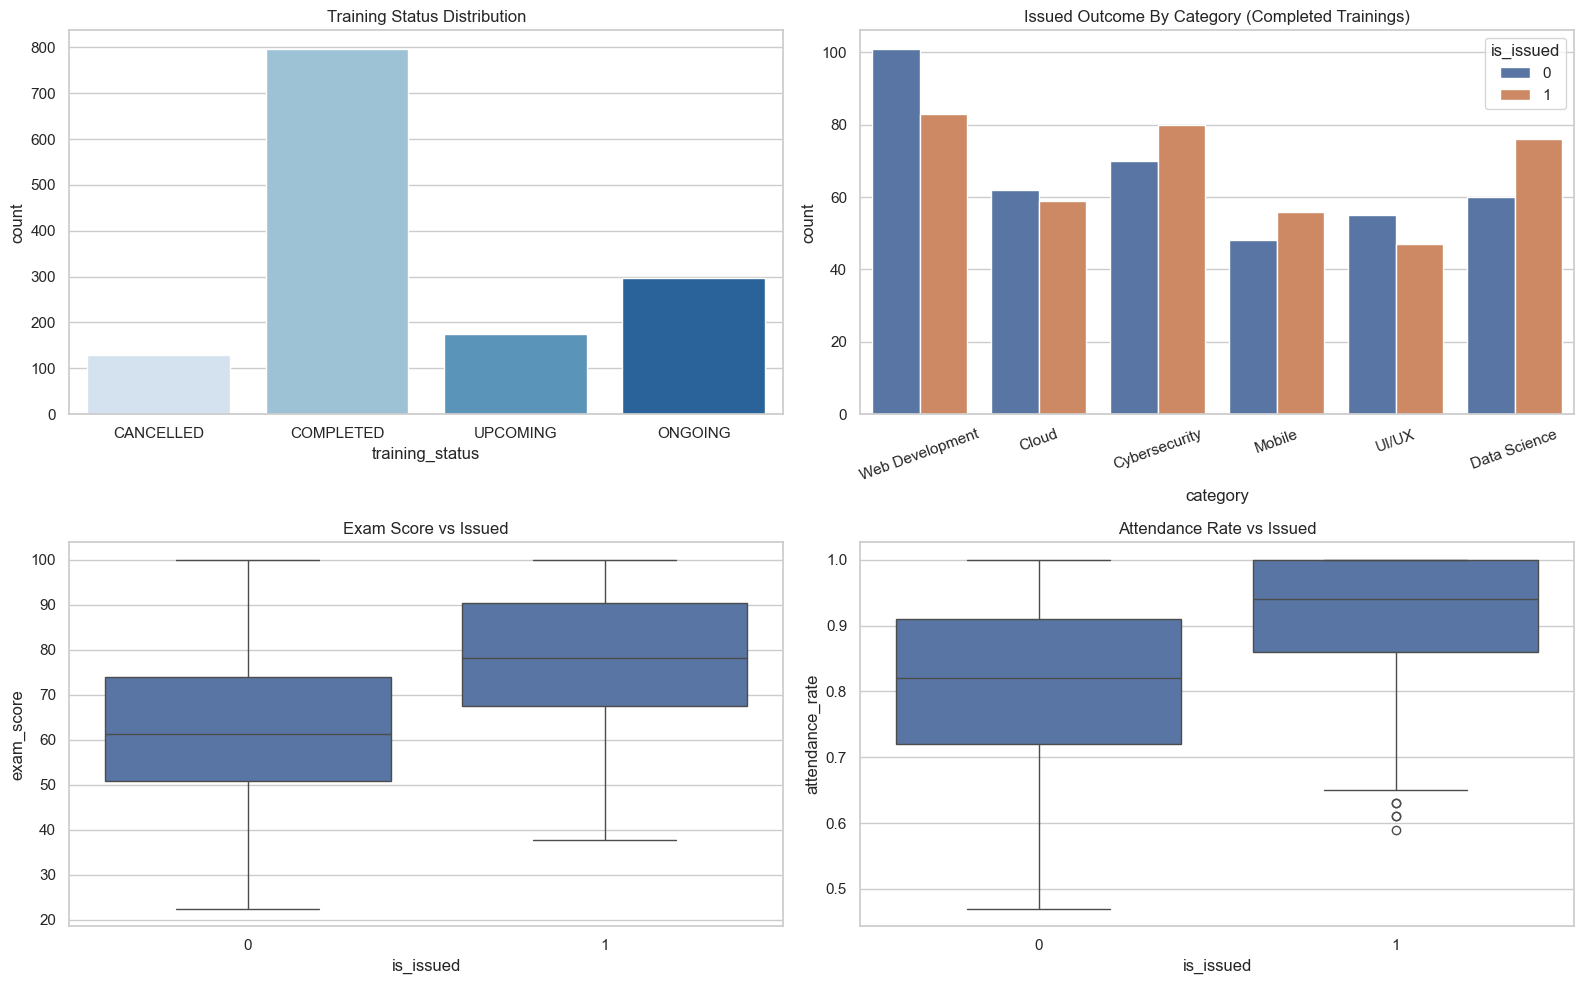

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='training_status', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Training Status Distribution')

sns.countplot(data=modeling_df, x='category', hue='is_issued', ax=axes[0, 1])
axes[0, 1].set_title('Issued Outcome By Category (Completed Trainings)')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.boxplot(data=modeling_df, x='is_issued', y='exam_score', ax=axes[1, 0])
axes[1, 0].set_title('Exam Score vs Issued')

sns.boxplot(data=modeling_df, x='is_issued', y='attendance_rate', ax=axes[1, 1])
axes[1, 1].set_title('Attendance Rate vs Issued')

plt.tight_layout()
plt.show()

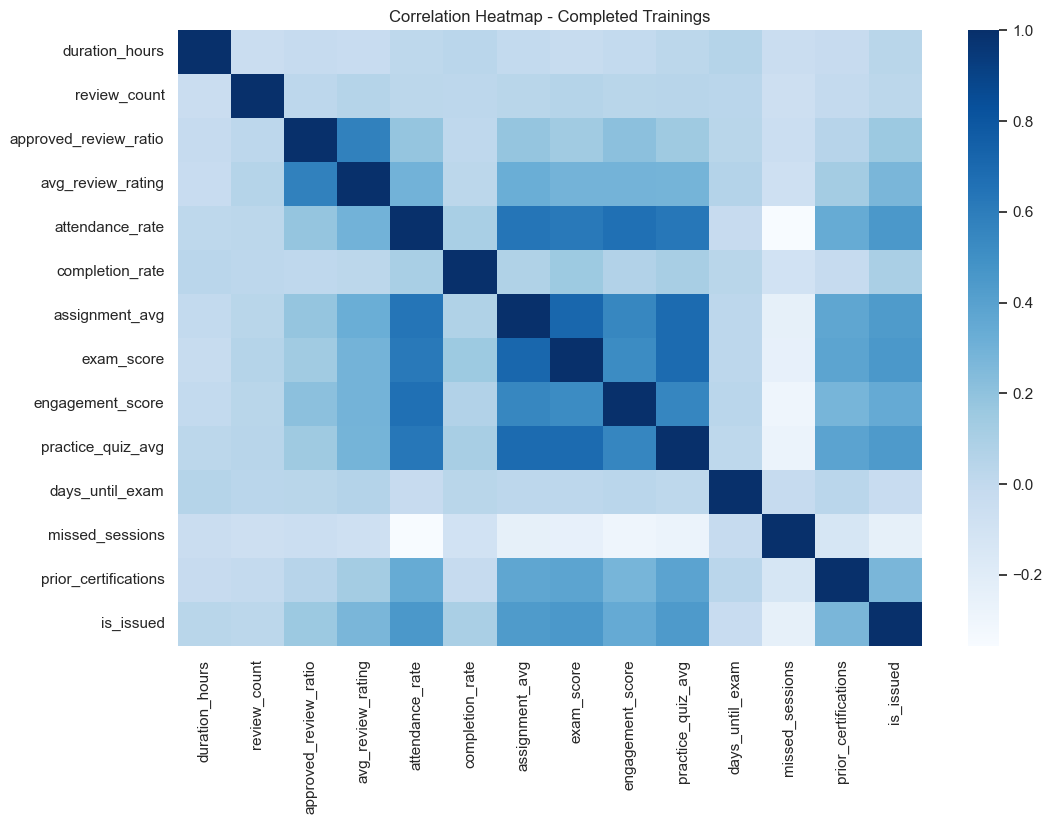

is_issued                1.000000
attendance_rate          0.450182
exam_score               0.449713
practice_quiz_avg        0.442993
assignment_avg           0.435771
engagement_score         0.342980
avg_review_rating        0.272921
prior_certifications     0.272382
approved_review_ratio    0.160095
completion_rate          0.102173
duration_hours           0.037846
review_count             0.026302
days_until_exam         -0.030302
missed_sessions         -0.240745
Name: is_issued, dtype: float64

In [7]:
numeric_cols = [
    'duration_hours',
    'review_count',
    'approved_review_ratio',
    'avg_review_rating',
    'attendance_rate',
    'completion_rate',
    'assignment_avg',
    'exam_score',
    'engagement_score',
    'practice_quiz_avg',
    'days_until_exam',
    'missed_sessions',
    'prior_certifications',
]

corr = modeling_df[numeric_cols + ['is_issued']].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='Blues', annot=False)
plt.title('Correlation Heatmap - Completed Trainings')
plt.show()

corr['is_issued'].sort_values(ascending=False)

## 7. Modeling Scope And Leakage Control

The model is intentionally trained on the `COMPLETED` subset only.

Why this is better:
- it respects the business process: issuance is evaluated after the training is completed
- it avoids a trivial classifier driven almost only by `training_status`
- it makes the classroom demonstration more honest and more useful

Columns excluded from the model on purpose:
- `certificate_status`
- `issue_date`
- `expiry_date`
- `issue_probability`
- `grade`
- `certificate_score`

These fields are post-decision fields or engineered summaries too close to the target, so using them would create leakage.

## 8. Preprocessing, Modeling, And Threshold Selection

This section explicitly addresses the old one-class prediction problem and tries to improve overall performance:
- a `DummyClassifier` baseline is kept to show what a weak majority-class model looks like
- richer engineered features are used on the completed-training subset
- the real models use class balancing
- an `ExtraTreesClassifier` is added because it often performs well on structured tabular data
- the decision threshold is selected on a validation set instead of always using `0.50`

In [8]:
feature_cols = [
    'category',
    'duration_hours',
    'training_duration_days',
    'review_count',
    'approved_review_ratio',
    'avg_review_rating',
    'attendance_rate',
    'completion_rate',
    'assignment_avg',
    'exam_score',
    'engagement_score',
    'practice_quiz_avg',
    'days_until_exam',
    'missed_sessions',
    'prior_certifications',
    'performance_index',
    'engagement_index',
    'review_quality_index',
    'days_since_training_end',
    'score_consistency',
    'engagement_gap',
]

target_col = 'is_issued'

X = modeling_df[feature_cols]
y = modeling_df[target_col]

categorical_features = ['category']
numerical_features = [col for col in feature_cols if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features),
])

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.25,
    random_state=42,
    stratify=y_train_valid,
)

models = {
    'DummyMostFrequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegressionBalanced': LogisticRegression(max_iter=3000, class_weight='balanced', C=1.2),
    'RandomForestBalanced': RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        class_weight='balanced_subsample',
    ),
    'ExtraTreesBalanced': ExtraTreesClassifier(
        n_estimators=600,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced',
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
threshold_grid = np.linspace(0.30, 0.70, 17)

results = []
threshold_searches = {}

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', clone(estimator)),
    ])

    cv_accuracy = cross_val_score(pipeline, X_train_valid, y_train_valid, cv=cv, scoring='accuracy').mean()
    cv_f1 = cross_val_score(pipeline, X_train_valid, y_train_valid, cv=cv, scoring='f1').mean()
    cv_roc_auc = cross_val_score(pipeline, X_train_valid, y_train_valid, cv=cv, scoring='roc_auc').mean()

    pipeline.fit(X_train, y_train)
    valid_probas = pipeline.predict_proba(X_valid)[:, 1]

    threshold_candidates = []
    for threshold in threshold_grid:
        valid_preds = (valid_probas >= threshold).astype(int)
        threshold_candidates.append({
            'threshold': float(threshold),
            'valid_accuracy': accuracy_score(y_valid, valid_preds),
            'valid_f1': f1_score(y_valid, valid_preds, zero_division=0),
            'valid_balanced_accuracy': balanced_accuracy_score(y_valid, valid_preds),
        })

    threshold_df = pd.DataFrame(threshold_candidates).sort_values(
        by=['valid_f1', 'valid_balanced_accuracy', 'valid_accuracy', 'threshold'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    selected_threshold = float(threshold_df.iloc[0]['threshold'])
    threshold_searches[name] = threshold_df

    valid_preds = (valid_probas >= selected_threshold).astype(int)
    test_probas = pipeline.predict_proba(X_test)[:, 1]
    test_preds = (test_probas >= selected_threshold).astype(int)

    results.append({
        'model': name,
        'selected_threshold': selected_threshold,
        'cv_accuracy_mean': cv_accuracy,
        'cv_f1_mean': cv_f1,
        'cv_roc_auc_mean': cv_roc_auc,
        'valid_accuracy': accuracy_score(y_valid, valid_preds),
        'valid_balanced_accuracy': balanced_accuracy_score(y_valid, valid_preds),
        'valid_precision': precision_score(y_valid, valid_preds, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_preds, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_preds, zero_division=0),
        'test_accuracy': accuracy_score(y_test, test_preds),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, test_preds),
        'test_precision': precision_score(y_test, test_preds, zero_division=0),
        'test_recall': recall_score(y_test, test_preds, zero_division=0),
        'test_f1': f1_score(y_test, test_preds, zero_division=0),
        'test_roc_auc': roc_auc_score(y_test, test_probas),
        'test_predicted_zeros': int((test_preds == 0).sum()),
        'test_predicted_ones': int((test_preds == 1).sum()),
    })

results_df = pd.DataFrame(results).sort_values(
    by=['valid_f1', 'valid_balanced_accuracy', 'valid_accuracy', 'cv_accuracy_mean', 'test_f1'],
    ascending=False,
).reset_index(drop=True)

results_df.to_csv(RESULTS_PATH, index=False)
results_df

,model,selected_threshold,cv_f1_mean,cv_roc_auc_mean,valid_accuracy,valid_balanced_accuracy,valid_precision,valid_recall,valid_f1,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_predicted_zeros,test_predicted_ones
0,LogisticRegressionBalanced,0.500,0.724546,0.802598,0.74375,0.74375,0.709677,0.8250,0.763006,0.71250,0.712768,0.727273,0.691358,0.708861,0.778872,83,77
1,RandomForestBalanced,0.525,0.733703,0.804897,0.74375,0.74375,0.724138,0.7875,0.754491,0.68125,0.681435,0.692308,0.666667,0.679245,0.778715,82,78
2,DummyMostFrequent,0.300,0.668761,0.500000,0.50000,0.50000,0.500000,1.0000,0.666667,0.50625,0.500000,0.506250,1.000000,0.672199,0.500000,0,160


## 9. Evaluation Of The Selected Model

The selected model is chosen using validation quality, not test performance alone.

What we want to see now:
- better performance than the dummy majority-class baseline
- stronger accuracy on the completed-training subset
- balanced predictions on the test set
- a threshold that produces both `0` and `1`
- metrics that are understandable and defendable during the presentation

Selected model: LogisticRegressionBalanced
Selected threshold: 0.5
Train size: 477 | Validation size: 160 | Test size: 160


,model,selected_threshold,valid_f1,valid_balanced_accuracy,test_f1,test_balanced_accuracy,test_roc_auc,test_predicted_zeros,test_predicted_ones
0,LogisticRegressionBalanced,0.500,0.763006,0.74375,0.708861,0.712768,0.778872,83,77
1,RandomForestBalanced,0.525,0.754491,0.74375,0.679245,0.681435,0.778715,82,78
2,DummyMostFrequent,0.300,0.666667,0.50000,0.672199,0.500000,0.500000,0,160



Classification report:

              precision    recall  f1-score   support

           0       0.68      0.71      0.70        79
           1       0.71      0.68      0.69        81

    accuracy                           0.69       160
   macro avg       0.69      0.69      0.69       160
weighted avg       0.69      0.69      0.69       160



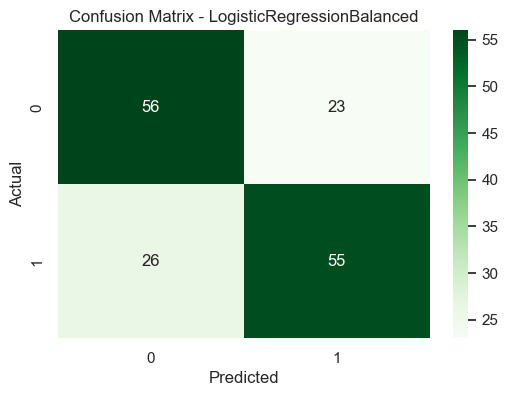

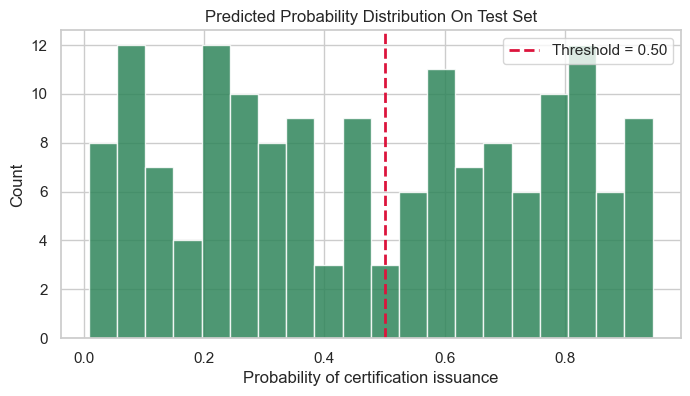

Predicted labels on test set:
0    82
1    78
Name: count, dtype: int64


In [9]:
best_model_name = results_df.iloc[0]['model']
selected_threshold = float(results_df.iloc[0]['selected_threshold'])

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', clone(models[best_model_name])),
])
final_pipeline.fit(X_train_valid, y_train_valid)

final_test_probas = final_pipeline.predict_proba(X_test)[:, 1]
final_test_preds = (final_test_probas >= selected_threshold).astype(int)

print('Selected model:', best_model_name)
print('Selected threshold:', round(selected_threshold, 2))
print('Train size:', X_train.shape[0], '| Validation size:', X_valid.shape[0], '| Test size:', X_test.shape[0])

display(
    results_df[
        [
            'model',
            'selected_threshold',
            'cv_accuracy_mean',
            'valid_accuracy',
            'valid_f1',
            'test_accuracy',
            'test_f1',
            'test_balanced_accuracy',
            'test_roc_auc',
            'test_predicted_zeros',
            'test_predicted_ones',
        ]
    ]
)

print('\nClassification report:\n')
print(classification_report(y_test, final_test_preds, zero_division=0))

cm = confusion_matrix(y_test, final_test_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(final_test_probas, bins=20, color='#2f855a', alpha=0.85)
plt.axvline(selected_threshold, color='crimson', linestyle='--', linewidth=2, label=f'Threshold = {selected_threshold:.2f}')
plt.title('Predicted Probability Distribution On Test Set')
plt.xlabel('Probability of certification issuance')
plt.ylabel('Count')
plt.legend()
plt.show()

print('Predicted labels on test set:')
print(pd.Series(final_test_preds).value_counts().sort_index())

In [10]:
top_thresholds = threshold_searches[best_model_name].head(8)
print('Top threshold candidates for the selected model:')
display(top_thresholds)

Top threshold candidates for the selected model:


,threshold,valid_f1,valid_balanced_accuracy
0,0.500,0.763006,0.74375
1,0.525,0.760736,0.75625
2,0.450,0.759777,0.73125
3,0.475,0.754286,0.73125
4,0.425,0.754098,0.71875
5,0.400,0.748663,0.70625
6,0.575,0.748299,0.76875
7,0.550,0.746835,0.75000


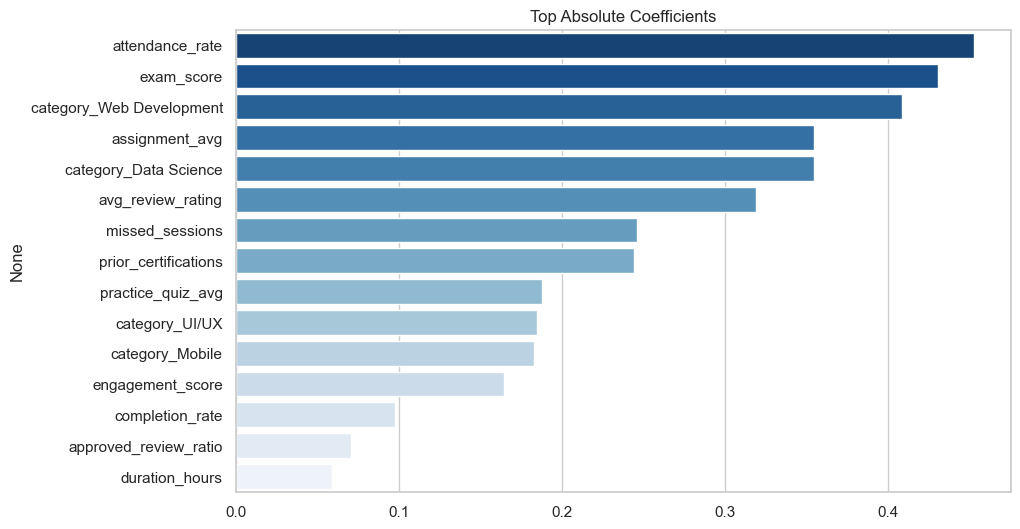

attendance_rate             0.452550
exam_score                  0.430575
category_Web Development    0.408336
assignment_avg              0.354446
category_Data Science       0.354282
avg_review_rating           0.318842
missed_sessions             0.245634
prior_certifications        0.244225
practice_quiz_avg           0.187363
category_UI/UX              0.184804
category_Mobile             0.182796
engagement_score            0.164023
completion_rate             0.097433
approved_review_ratio       0.070343
duration_hours              0.059132
dtype: float64

In [11]:
trained_model = final_pipeline.named_steps['model']
ohe = final_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numerical_features + encoded_cat_names

if hasattr(trained_model, 'feature_importances_'):
    importance_values = trained_model.feature_importances_
    importance_title = 'Top Feature Importances'
else:
    importance_values = np.abs(trained_model.coef_[0])
    importance_title = 'Top Absolute Coefficients'

feature_importance = pd.Series(importance_values, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='Blues_r')
plt.title(importance_title)
plt.show()

display(feature_importance)

## 10. Example Predictions

In [12]:
demo_candidates = pd.DataFrame([
    {
        'profile': 'Strong learner likely to receive certification',
        'category': 'Data Science',
        'duration_hours': 60,
        'review_count': 11,
        'approved_review_ratio': 0.91,
        'avg_review_rating': 4.7,
        'attendance_rate': 0.95,
        'completion_rate': 0.98,
        'assignment_avg': 90.0,
        'exam_score': 92.0,
        'engagement_score': 88.0,
        'practice_quiz_avg': 89.0,
        'days_until_exam': 4,
        'missed_sessions': 0,
        'prior_certifications': 2,
    },
    {
        'profile': 'Borderline learner needing support',
        'category': 'Cloud',
        'duration_hours': 52,
        'review_count': 6,
        'approved_review_ratio': 0.52,
        'avg_review_rating': 3.4,
        'attendance_rate': 0.72,
        'completion_rate': 0.81,
        'assignment_avg': 64.0,
        'exam_score': 61.0,
        'engagement_score': 58.0,
        'practice_quiz_avg': 60.0,
        'days_until_exam': 8,
        'missed_sessions': 3,
        'prior_certifications': 0,
    },
    {
        'profile': 'High-risk learner unlikely to receive certification',
        'category': 'Web Development',
        'duration_hours': 42,
        'review_count': 3,
        'approved_review_ratio': 0.28,
        'avg_review_rating': 2.4,
        'attendance_rate': 0.54,
        'completion_rate': 0.69,
        'assignment_avg': 49.0,
        'exam_score': 46.0,
        'engagement_score': 41.0,
        'practice_quiz_avg': 44.0,
        'days_until_exam': 10,
        'missed_sessions': 6,
        'prior_certifications': 0,
    },
])

demo_probas = final_pipeline.predict_proba(demo_candidates[feature_cols])[:, 1]
demo_preds = (demo_probas >= selected_threshold).astype(int)

demo_results = demo_candidates.copy()
demo_results['predicted_probability'] = np.round(demo_probas, 4)
demo_results['predicted_label'] = demo_preds

display(demo_results)

,profile,category,duration_hours,review_count,approved_review_ratio,avg_review_rating,attendance_rate,completion_rate,assignment_avg,exam_score,engagement_score,practice_quiz_avg,days_until_exam,missed_sessions,prior_certifications,predicted_probability,predicted_label
0,Strong learner likely to receive certification,Data Science,60,11,0.91,4.7,0.95,0.98,90.0,92.0,88.0,89.0,4,0,2,0.9436,1
1,Borderline learner needing support,Cloud,52,6,0.52,3.4,0.72,0.81,64.0,61.0,58.0,60.0,8,3,0,0.1127,0
2,High-risk learner unlikely to receive certific...,Web Development,42,3,0.28,2.4,0.54,0.69,49.0,46.0,41.0,44.0,10,6,0,0.0039,0


## 11. Save Artifacts

In [13]:
artifact = {
    'pipeline': final_pipeline,
    'threshold': float(selected_threshold),
    'features': feature_cols,
    'best_model_name': best_model_name,
    'snapshot_date': str(SNAPSHOT_DATE.date()),
    'results': results_df.to_dict(orient='records'),
}

joblib.dump(artifact, MODEL_PATH)

print(f'Full dataset saved to: {DATASET_PATH.resolve()}')
print(f'Completed-only modeling dataset saved to: {MODELING_DATASET_PATH.resolve()}')
print(f'Model artifact saved to: {MODEL_PATH.resolve()}')
print(f'Model comparison saved to: {RESULTS_PATH.resolve()}')
print(f'Data quality report saved to: {QUALITY_PATH.resolve()}')

Full dataset saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_data\training_certifications_dataset.csv
Completed-only modeling dataset saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_data\completed_training_certifications_dataset.csv
Model artifact saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_models\certification_issued_pipeline.joblib
Model comparison saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_reports\model_comparison_results.csv
Data quality report saved to: C:\Users\MSI\Desktop\PIDEV4\Esprit-PIDEV-4SAE5-2026-SmartFreelancePlatform\ml_reports\data_quality_report.csv


## 12. Deployment Plan Compatible With A Java Backend

Because the backend is Spring Boot Java and the trained artifact is a Python `joblib` file, the most realistic deployment option is:

1. keep model training in Python
2. expose inference through a lightweight Python API, for example FastAPI or Flask
3. call that service from the Java backend when a completed training snapshot is ready
4. return:
   - predicted label
   - issuance probability
   - threshold used
   - model version

Recommended request payload:
- category
- durationHours
- reviewCount
- approvedReviewRatio
- avgReviewRating
- attendanceRate
- completionRate
- assignmentAvg
- examScore
- engagementScore
- practiceQuizAvg
- daysUntilExam
- missedSessions
- priorCertifications

Recommended response payload:
- `probabilityIssued`
- `predictedIssued`
- `threshold`
- `modelName`
- `snapshotDate`

This is more authentic than pretending a Java backend can directly load a Python `joblib` pipeline.

## 13. PI Report Summary

This notebook now supports a stronger PI narrative:

Business understanding
- predict certification issuance after training completion

Data acquisition and understanding
- synthetic but backend-aligned snapshot generated on `2026-04-16`
- date logic is explicitly constrained by status and lifecycle rules

Data preparation
- explicit checks for missing values, duplicates, validity, date logic, and coherence
- engineered features improve readability and predictive quality

Modeling and evaluation
- leakage-aware feature selection
- dummy baseline plus multiple balanced models
- validation-based threshold selection
- stronger accuracy-focused comparison on the completed-training subset

Deployment
- saved artifact
- CSV exports
- deployment plan consistent with a Java backend

Why this version is more defendable
- the dates are much more coherent
- the feature space is richer and more realistic
- the model comparison is stronger
- it avoids the trivial one-class prediction trap
- it gives you concrete artifacts to show to the teacher